# **Personal Health Mood & Habit Tracker**

In [ ]:
# importing libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


In [ ]:
# loading the dataset
df = pd.read_csv('/content/drive/MyDrive/Datasets/Daily_Habit_Tracker.csv')

In [ ]:
# printing head of the data
df.head()

,User_ID,Date,Wake_Up_Time,Sleep_Hours,Steps,Calories_Burned,Water_Intake_ml,Study_Hours,Mood_Score
0,U001,2025-09-17,07:02,5.8,19772,2645,571,0.4,2
1,U002,2025-07-15,05:27,5.0,14764,3325,4890,4.1,6
2,U003,2025-05-02,08:32,5.7,2225,1954,3183,4.6,1
3,U004,2025-10-25,06:42,9.4,4055,2144,2530,3.3,4
4,U005,2025-02-02,05:54,5.3,4314,2729,4028,2.5,8


In [ ]:
# checking the composition of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User_ID          500 non-null    object 
 1   Date             500 non-null    object 
 2   Wake_Up_Time     500 non-null    object 
 3   Sleep_Hours      500 non-null    float64
 4   Steps            500 non-null    int64  
 5   Calories_Burned  500 non-null    int64  
 6   Water_Intake_ml  500 non-null    int64  
 7   Study_Hours      500 non-null    float64
 8   Mood_Score       500 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 35.3+ KB


In [ ]:
df.describe()

,Sleep_Hours,Steps,Calories_Burned,Water_Intake_ml,Study_Hours,Mood_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,7.255600,10618.602000,2509.752000,2761.040000,4.04200,5.712000
std,1.298955,5801.809012,755.647323,1312.905309,2.38038,2.961519
min,5.000000,567.000000,1206.000000,509.000000,0.00000,1.000000
25%,6.100000,5861.250000,1866.250000,1618.000000,2.10000,3.000000
50%,7.300000,10668.500000,2552.500000,2749.000000,4.00000,6.000000
75%,8.300000,15837.000000,3162.000000,3873.500000,6.30000,8.000000
max,9.500000,19960.000000,3791.000000,4992.000000,8.00000,10.000000


In [ ]:
# checking for null values
df.isnull().sum()

,0
User_ID,0
Date,0
Wake_Up_Time,0
Sleep_Hours,0
Steps,0
Calories_Burned,0
Water_Intake_ml,0
Study_Hours,0
Mood_Score,0


## **Data cleaning**

In [ ]:
# function to change the format of time column
def time_to_decimal(time_str):
  hours, minutes = map(int, time_str.split(':'))
  return hours + (minutes / 60)


In [ ]:
# converting the format of time column
df['Wake_Up_Time'] = df['Wake_Up_Time'].apply(time_to_decimal)

In [ ]:
# dropping the columns that we don't need
df = df.drop(columns=['User_ID','Date'])

In [ ]:
df.head()

,Wake_Up_Time,Sleep_Hours,Steps,Calories_Burned,Water_Intake_ml,Study_Hours,Mood_Score
0,7.033333,5.8,19772,2645,571,0.4,2
1,5.450000,5.0,14764,3325,4890,4.1,6
2,8.533333,5.7,2225,1954,3183,4.6,1
3,6.700000,9.4,4055,2144,2530,3.3,4
4,5.900000,5.3,4314,2729,4028,2.5,8


## **Training the actual model**

In [ ]:
# feature engineering
X = df[['Wake_Up_Time','Sleep_Hours','Steps','Calories_Burned','Water_Intake_ml','Study_Hours']]
y = df['Mood_Score']

In [ ]:
# splitting the data into training and testing data
X_test, X_train, y_test, y_train = train_test_split(X,y ,random_state= 42)

In [ ]:
# defining the model
model = RandomForestRegressor(n_estimators=100 ,random_state= 42)

In [ ]:
# training the model
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# predictions from trained model
y_pred = model.predict(X_test)

In [ ]:
# evaluating the model
print(mean_absolute_error(y_pred,y_test))

2.6679199999999996


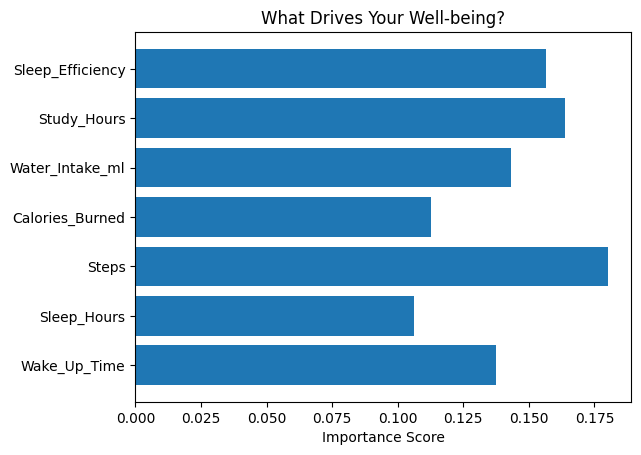

In [ ]:
# get important features
importances = model.feature_importances_
feature_names = X.columns

# Visualize
plt.barh(feature_names, importances)
plt.xlabel("Importance Score")
plt.title("What Drives Your Well-being?")
plt.show()

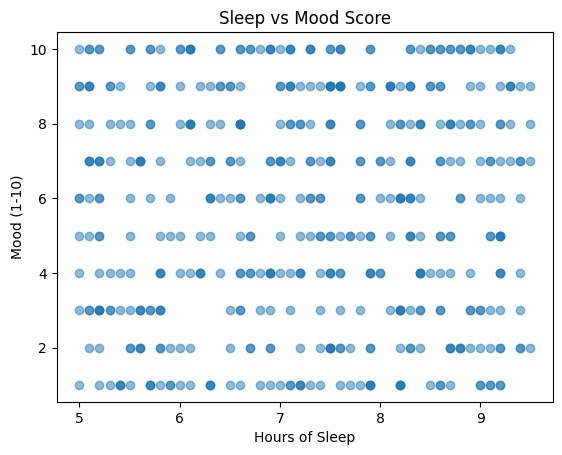

In [ ]:
plt.scatter(df['Sleep_Hours'], df['Mood_Score'], alpha=0.5)
plt.title('Sleep vs Mood Score')
plt.xlabel('Hours of Sleep')
plt.ylabel('Mood (1-10)')
plt.show()

In [ ]:
# changing the relationships
np.random.seed(42)
days = 100
sleep = np.random.uniform(5, 10, days)
water = np.random.uniform(1, 4, days)
steps = np.random.randint(2000, 15000, days)

# Mood is 50% sleep and 30% steps
# adding random noise
mood = (sleep * 0.7) + (steps / 5000) + np.random.normal(0, 0.5, days)
mood = np.clip(mood, 1, 10) # Keep mood between 1 and 10


df_new = pd.DataFrame({
    'Sleep_Hours': sleep,
    'Water_Liters': water,
    'Steps': steps,
    'Mood_Score': mood
})
df_new.to_csv('High_Signal_Habits.csv', index=False)
print("New dataset created with strong patterns!")

New dataset created with strong patterns!


In [ ]:
df_new.head()

,Sleep_Hours,Water_Liters,Steps,Mood_Score
0,6.872701,1.094288,14183,7.965047
1,9.753572,2.909231,14915,9.270400
2,8.659970,1.943068,14874,8.383930
3,7.993292,2.525712,3648,5.949524
4,5.780093,3.722699,7539,5.041115


In [ ]:
# feature engineering
X1 = df_new[['Sleep_Hours','Steps','Water_Liters']]
y1 = df_new['Mood_Score']

In [ ]:
# splitting the data into training and testing data
X1_test, X1_train, y1_test, y1_train = train_test_split(X1,y1 ,random_state= 42)

In [ ]:
model1 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)

In [ ]:
# training the model
model1.fit(X1_train,y1_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
# predictions from trained model
y_pred1 = model1.predict(X1_test)

In [ ]:
y_pred2 = model1.predict(X1_train)

In [ ]:
# evaluating the model
print(mean_absolute_error(y_pred2,y1_train))
print(mean_absolute_error(y_pred1,y1_test))

0.2054002725583328
0.643273235079836


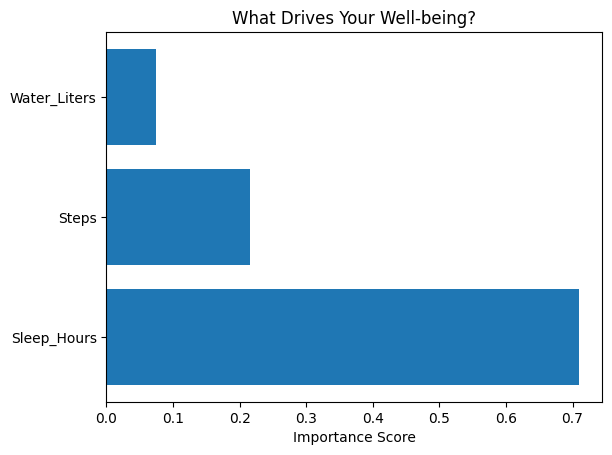

In [ ]:
# get important features
importances = model1.feature_importances_
feature_names = X.columns

# Visualize
plt.barh(feature_names, importances)
plt.xlabel("Importance Score")
plt.title("What Drives Your Well-being?")
plt.show()

In [ ]:

sleep_val = float(input('Enter your sleep hours: '))
steps_val = int(input('Enter your steps: '))
water_val = float(input('Enter your water intake in liters: '))


user_features = np.array([[sleep_val, steps_val, water_val]])


prediction = model1.predict(user_features)

print(f"\n--- Result ---")
print(f"Predicted Wellbeing Score: {prediction[0]:.2f}")

if prediction[0] > 7:
    print("Advice: You're doing great! Keep this routine up.")
elif prediction[0] > 5:
    print("Advice: Not bad, but maybe try to get an extra hour of sleep tonight.")
else:
    print("Advice: Focus on recovery today. Hydrate and rest!")

Enter your sleep hours: 7
Enter your steps: 15000
Enter your water intake in liters: 7

--- Result ---
Predicted Wellbeing Score: 8.30
Advice: You're doing great! Keep this routine up.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
